In [79]:
%conda install conda-forge::html5lib

Channels:
 - defaults
 - conda-forge
 - pytorch
 - huggingface
Platform: linux-64
Solving environment: done

## Package Plan ##

  environment location: /home/bstenger/anaconda3/envs/quarto

  added / updated specs:
    - conda-forge::html5lib


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    html5lib-1.1               |     pyhd8ed1ab_2          93 KB  conda-forge
    ------------------------------------------------------------
                                           Total:          93 KB

The following NEW packages will be INSTALLED:

  html5lib           conda-forge/noarch::html5lib-1.1-pyhd8ed1ab_2 



                                                                                
Preparing transaction: done
Verifying transaction: done
Executing transaction: done

Note: you may need to restart the kernel to use updated packages.


In [146]:
#2025 NHL injuries
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np

inj_url = "https://www.spotrac.com/nhl/injured/_/year/2025/view/player"
headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"} # Mimic a browser
response = requests.get(inj_url, headers=headers)
soup = BeautifulSoup(response.text, "html.parser")
df_nhl = pd.read_html(str(soup.find('table',id="table")))[0]
df_nhl['Reason'] = df_nhl['Reason'].str.replace('TBD','4/16/26',regex=False)
df_nhl['Reason'] = df_nhl['Reason'].str.replace(r" (\d+/\d+)-(\d+/\d+/)(\d+)",r" \1/\3-\2\3",regex=True)
df_nhl = df_nhl.assign(Reason=df_nhl['Reason'].str.split(',')).explode('Reason')
df_nhl = df_nhl.assign(Reason=df_nhl['Reason'].str.split(r"(.*?: .*?: \d+/\d+/\d+-\d+/\d+/\d+)")).explode('Reason')
df_nhl = df_nhl.replace('', np.nan)
df_nhl = df_nhl.dropna()
df_nhl[["start","end"]] = df_nhl['Reason'].str.extract(r"(\d+/\d+/\d+)-(\d+/\d+/\d+)")
group_nhl = df_nhl[["Player","Team","start","end"]].groupby("Team")


/tmp/ipykernel_62142/3979495055.py:11: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df_nhl = pd.read_html(str(soup.find('table',id="table")))[0]


In [147]:
sal_url = "https://www.spotrac.com/nhl/rankings/player/_/year/2025/sort/cash_total"
sal_response = requests.get(sal_url, headers=headers)
sal_soup = BeautifulSoup(sal_response.text, "html5lib").find('div',id="table")
players = [span.get_text(strip=True) for span in sal_soup.find_all("a")]
salaries = [int(span.get_text(strip=True).replace("$","").replace(",","")) for span in sal_soup.find_all("span",class_="medium")]
season = (pd.to_datetime("4/16/2026") - pd.to_datetime("10/7/2025")).days
daysalaries = [round(pay/season, 2) for pay in salaries]
lookup_players = dict(zip(players, daysalaries))
lookup_players["Matej Blumel"] = round(775000/season,2)
lookup_players["Michael Callahan"] = round(775000/season,2)
lookup_players["Charles-Alexis Legault"] = round(832500/season,2)
lookup_players["Laurent Brossoit"] = round(2300000/season,2)
lookup_players["Joseph Anderson"] = round(800000/season, 2)
lookup_players["Gavin Brindley"] = round(855000/season, 2)
lookup_players["Nikita Prishchepov"] = round(775000/season, 2)
lookup_players["Noah Philip"] = round(775000/season,2)
lookup_players["Connor Clattenburg"] = round(775000/season,2)
lookup_players["Alec Regula"] = round(775000/season,2)
lookup_players["Tobias Bjornfot"] = round(775000/season,2)
lookup_players["Juho Lammikko"] = round(800000/season, 2)
lookup_players["Seamus Casey"] = round(855000/season,2)
lookup_players["Olle Lycksell"] = round(775000/season,2)
lookup_players["Rutger McGroarty"] = round(855000/season,2)
lookup_players["Ville Koivunen"] = round(775000/season,2)
lookup_players["Joel Blomqvist"] = round(832500/season, 2)
lookup_players["Jeff Skinner"] = round(3000000/season,2)
lookup_players["Dakota Mermis"] = round(775000/season,2)
lookup_players["Marshall Rifai"] = round(775000/season,2)
lookup_players["Jonathan Lekkerimaki"] = round(855000/season,2)
lookup_players["Jonas Rondbjerg"] = round(775000/season,2)


In [145]:
pay_url = "https://www.spotrac.com/nhl/cash/_/year/2025"
headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"} # Mimic a browser
pay_response = requests.get(pay_url, headers=headers)
pay_soup = BeautifulSoup(pay_response.text, "html.parser")
df_nhl_pay = pd.read_html(str(pay_soup.find('table',class_="table dataTable")))[0]
seasonpay = df_nhl_pay['Active'].str.replace(r'[\$,]', '', regex=True).astype(int)
daypay = [round(pay/season, 2) for pay in seasonpay]
lookup_teams = dict(zip(df_nhl_pay['Team'].str.replace(r"(\w+) .*",r"\1",regex=True), daypay))
lookup_teams

/tmp/ipykernel_62142/3178108624.py:5: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df_nhl_pay = pd.read_html(str(pay_soup.find('table',class_="table dataTable")))[0]


{'VGK': 531940.44,
 'DAL': 527265.81,
 'FLA': 473550.12,
 'NYR': 478261.78,
 'NJD': 523357.8,
 'TBL': 486313.71,
 'STL': 413969.88,
 'TOR': 487628.4,
 'MTL': 504994.83,
 'BOS': 538347.35,
 'EDM': 395439.9,
 'UTA': 503135.83,
 'WAS': 451112.96,
 'CAR': 508105.48,
 'PHI': 436939.65,
 'COL': 497441.97,
 'VAN': 374802.03,
 'SEA': 451502.18,
 'NYI': 372831.9,
 'MIN': 482092.5,
 'BUF': 463419.27,
 'OTT': 484368.38,
 'LAK': 362149.43,
 'WPG': 451654.7,
 'PIT': 382565.68,
 'CBJ': 423422.77,
 'NSH': 419390.81,
 'SJS': 291688.58,
 'DET': 398901.65,
 'CGY': 310458.59,
 'ANA': 350336.52,
 'CHI': 282766.53,
 'Totals': 14060157.4,
 'Averages': 439379.92}

In [148]:
whichteam = "EDM"
whichplayer = "Leon Draisaitl"
oneteam = group_nhl.get_group(whichteam)
# calc date differences, sets of injured dates
# 2025-26 nhl season starts on Oct 7, ends on Apr 16, 174 days
#pd.to_datetime(df_nhl['end']) - pd.to_datetime(df_nhl['start'])
#set(pd.date_range(start=pd.to_datetime(df_nhl['start']), end=pd.to_datetime(df_nhl['end'])))
nhl_days = list(pd.date_range(start=pd.to_datetime("10/7/2025"), end=pd.to_datetime("4/16/2026")))
payteam = lookup_teams[whichteam]
injurycost = pd.DataFrame({"seasonday":nhl_days,"cost":0})
oneteam["injurydays"] = [pd.date_range(start,end).tolist() for start, end in zip(oneteam["start"],oneteam["end"])]
player_injurydays = oneteam.loc[oneteam["Player"] == whichplayer, "injurydays"].values[0]
injurycost["cost"] = np.where(injurycost["seasonday"].isin(player_injurydays), injurycost["cost"] + lookup_players[whichplayer], injurycost["cost"])
injurycost


/tmp/ipykernel_62142/495045522.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  oneteam["injurydays"] = [pd.date_range(start,end).tolist() for start, end in zip(oneteam["start"],oneteam["end"])]


,seasonday,cost
0,2025-10-07,0.00
1,2025-10-08,0.00
2,2025-10-09,0.00
3,2025-10-10,0.00
4,2025-10-11,0.00
...,...,...
187,2026-04-12,86387.43
188,2026-04-13,86387.43
189,2026-04-14,86387.43
190,2026-04-15,86387.43


In [157]:
whichteam = "ANA"
injurycost = pd.DataFrame({"seasonday":nhl_days,"cost":0,"bodycount":0})
oneteam = group_nhl.get_group(whichteam)
oneteam["injurydays"] = [pd.date_range(start,end).tolist() for start, end in zip(oneteam["start"],oneteam["end"])]
for whichplayer,player_injurydays in zip(oneteam["Player"],oneteam["injurydays"]):
    injurycost["cost"] = np.where(injurycost["seasonday"].isin(player_injurydays), injurycost["cost"] + lookup_players[whichplayer], injurycost["cost"])
    injurycost["pct"] = round(injurycost["cost"]/lookup_teams[whichteam],2)
    injurycost["bodycount"] = np.where(injurycost["seasonday"].isin(player_injurydays), injurycost["bodycount"] + 1, injurycost["bodycount"])
injurycost

/tmp/ipykernel_62142/3761922923.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  oneteam["injurydays"] = [pd.date_range(start,end).tolist() for start, end in zip(oneteam["start"],oneteam["end"])]


,seasonday,cost,bodycount,pct
0,2025-10-07,4188.48,1,0.01
1,2025-10-08,4188.48,1,0.01
2,2025-10-09,9914.99,2,0.03
3,2025-10-10,9914.99,2,0.03
4,2025-10-11,9914.99,2,0.03
...,...,...,...,...
187,2026-04-12,19109.95,1,0.05
188,2026-04-13,19109.95,1,0.05
189,2026-04-14,19109.95,1,0.05
190,2026-04-15,19109.95,1,0.05


In [ ]:
graphdata = []
for whichteam, oneteam in group_nhl:
    injurycost = pd.DataFrame({"seasonday":nhl_days, "cost":0, "bodycount":0})
    oneteam["injurydays"] = [pd.date_range(start,end).tolist() for start, end in zip(oneteam["start"],oneteam["end"])]
    for whichplayer, player_injurydays in zip(oneteam["Player"],oneteam["injurydays"]):
        injurycost["cost"] = np.where(injurycost["seasonday"].isin(player_injurydays), injurycost["cost"] + lookup_players[whichplayer], injurycost["cost"])
        injurycost["pct"] = round(injurycost["cost"] / lookup_teams[whichteam],2)
        injurycost["bodycount"] = np.where(injurycost["seasonday"].isin(player_injurydays), injurycost["bodycount"] + 1, injurycost["bodycount"])
    graphdata.append({"team":whichteam,"days":nhl_days,"dailypct":injurycost["pct"].tolist(),"dailybodycount":injurycost["bodycount"].tolist()})
graphdata

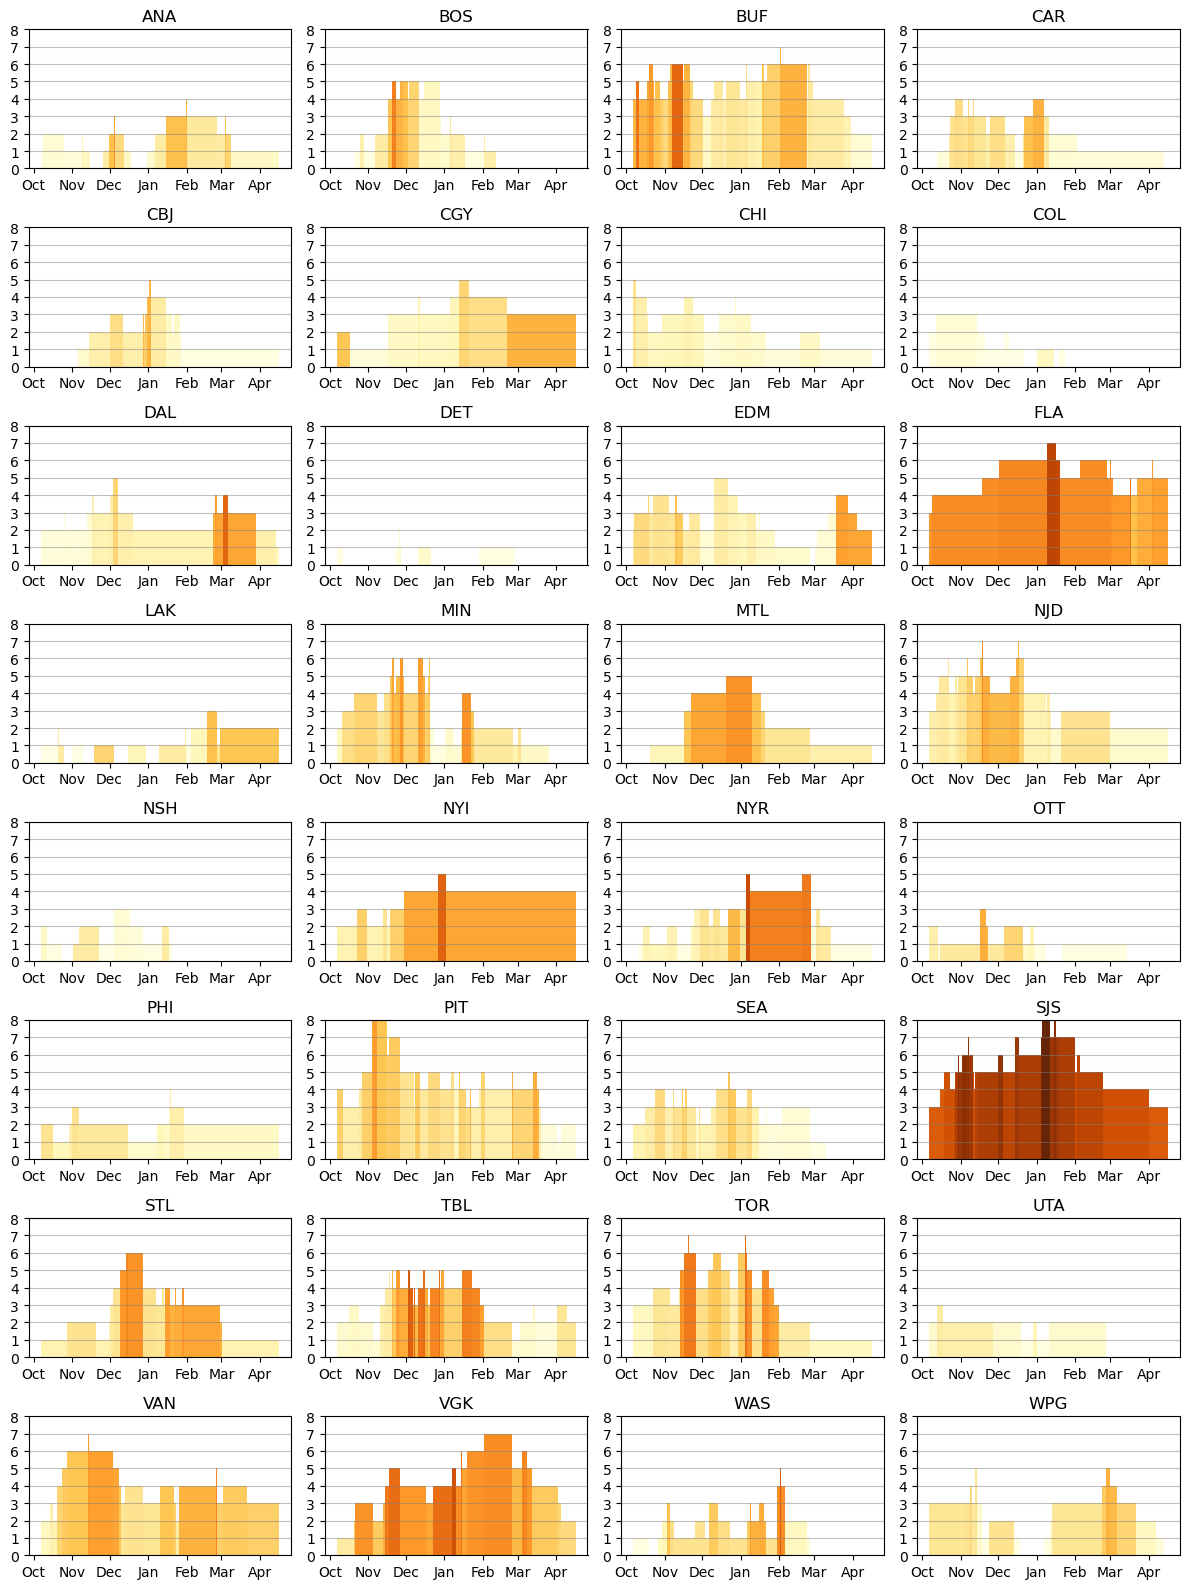

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator

df_ic = pd.DataFrame(graphdata)
df_ic = df_ic.explode(["days","dailypct","dailybodycount"])
df_ic[["dailypct","dailybodycount"]] = df_ic[["dailypct","dailybodycount"]].astype(float)
eachteam = df_ic.groupby("team")
howmany_teams = len(grouped)
fig, axes = plt.subplots(
    nrows=int(howmany_teams/4), 
    ncols = 4, 
    figsize=(12,0.5*howmany_teams), 
    squeeze=False
)
cmap = plt.get_cmap('YlOrBr')
norm = mcolors.Normalize(0, df_ic["dailypct"].max())
axes_flat = axes.flatten()
for i, (group_name, group_df) in enumerate(eachteam):
    ax = axes_flat[i]
    img = ax.bar(
        group_df["days"],
        group_df["dailybodycount"],
        color=cmap(norm(group_df["dailypct"])),
        width=1.0,
        edgecolor='none',
        align='center'
    )
    ax.set_ylim(0,8)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=8))
    ax.grid(True, axis='y',color='gray',alpha=0.75)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    ax.set_title(group_name)
plt.tight_layout()
plt.show()


In [173]:
data = []
years = np.arange(1920, 2027)
trend = np.linspace(-1.5, 2.0, len(years)) + np.random.normal(0, 0.4, len(years))
for yr, val in zip(years,trend):
    data.append({"Region":"north","Year":yr,"TA":val})
pd.DataFrame(data)

,Region,Year,TA
0,north,1920,-1.455462
1,north,1921,-1.084425
2,north,1922,-1.647527
3,north,1923,-0.704161
4,north,1924,-1.434398
...,...,...,...
102,north,2022,1.861123
103,north,2023,2.306496
104,north,2024,1.485379
105,north,2025,1.755511
